# Pipeline Dataset Airbnb da cidade do Rio de Janeiro

_**Aluna:** Julia Farah_

_**Data de entrega:** 21/12/2025_

_**Matrícula:** 4052025001969_

## Apresentação do Dataset
Os dados brutos (Raw) estão disponíveis no GitHub para serem carregados na camada Bronze.
* **Fonte:** [Inside Airbnb](https://insideairbnb.com/get-the-data/) (Listings.csv) e Tabela Auxiliar com as [listas dos bairros por região](https://www.estadosecapitaisdobrasil.com/lista-dos-bairros-do-rio-de-janeiro/) (Zonas).

* As segmetação da paleta de cores utilizada neste MVP é de acordo com as cores oficiais do Airbnb disponíveis no site da [US Brand Colors](https://usbrandcolors.com/airbnb-colors/)

* **Descrição dos dados brutos (raw) da tabela `listings.csv` que serão importados para a camada bronze:**

`id` — Identificador do anúncio.

`name` — Título do anúncio.

`host_id` — Identificador do host (anfitrião).

`host_name` — Nome do host.

`neighbourhood_group` — Região em que o bairro está inserido.

`neighbourhood` — Nome do bairro.

`latitude` — Latitude geográfica.

`longitude` — Longitude geográfica.

`room_type` — O tipo da acomodação.

`price` — O valor da acomodação.

`minimum_nights` — Qtd mínimo de noites para reserva.

`number_of_reviews` — Quantos reviews (avaliações) a acomodação tem.

`last_review` — Data da ultima review feita.

`reviews_per_month` — Qtd de reviews por mês.

`calculated_host_listings_count` — Qtd de anúncios que o host (anfitrião) tem na cidade.

`availability_365` — Qtd de dias que a acomodação está disponível nos próximos 365 dias.

`number_of_reviews_ltm` — Qtd de reviews que o anúncio tem nos últimos 12 meses.

`license` — Número de registro.

* **Descrição da tabela `neighbourhoods.csv` que será importada do github que será usada para indicar a região (zona) geografica da cidade que cada bairro pertence:**

`id_bairros` — Identificador do bairro

`bairro` — Nome do bairro

`zona` — Região da cidade (central, oeste, sul e norte)

Neste MVP, transformei a tabela original `listings.csv` (_uma tabela flat com todas as informações misturadas_) em um **modelo _star schema_** composto por **1 Tabela Fato e 3 Tabelas Dimensão** combinado com a **arquitetura medalhão (Bronze, Silver & Gold)**.


### 1. Configuração e Leitura dos Dados (Camada BRONZE)

**1.1 Limpeza preventiva para ter certeza que não há nada pré-salvo (caso exista execuções anteriores)**

In [0]:
%sql
DROP TABLE IF EXISTS listings;
DROP TABLE IF EXISTS zonas_bairros;

DROP TABLE IF EXISTS dim_host;
DROP TABLE IF EXISTS dim_location;
DROP TABLE IF EXISTS dim_ad;


DROP TABLE IF EXISTS fact_listings;
DROP TABLE IF EXISTS df_fato_final;



**1.2 Criação dos schemas (pastas) da arquitetura medalhão:**

* Isso garante que a estrutura **bronze, silver e gold** seja criada no `catálogo`

In [0]:
%sql

CREATE SCHEMA IF NOT EXISTS bronze;
CREATE SCHEMA IF NOT EXISTS silver;
CREATE SCHEMA IF NOT EXISTS gold;


**1.3 Importação da biblioteca Pandas e PySpark**

In [0]:

import pandas as pd

from pyspark.sql.functions import col, monotonically_increasing_id, regexp_replace, current_timestamp, to_date, expr, row_number, when, count, trim, lit

import warnings
warnings.filterwarnings("ignore")

**1.4 Carregando os dados na camada BRONZE**

In [0]:

# Caminhos dos arquivos no Databricks Volumes (também disponiveis no GitHub)
path_listings = "/Volumes/workspace/airbnb_rio/listings/listings.csv"
path_regioes = "/Volumes/workspace/airbnb_rio/neighbourhoods/neighbourhoods.csv"

# Função auxiliar para ler do GitHub e converter para Spark DataFrame
def ler_tabela_do_github(caminho, sep, encoding):
    
    pdf = pd.read_csv(caminho, sep=sep, encoding=encoding)
    pdf.columns = pdf.columns.str.strip() # remove espaços em branco antes e depois do nome da coluna
    pdf = pdf.astype(str) # coloca tudo como string pra evitar erros no spark
    df_spark = spark.createDataFrame(pdf) # converte do pandas pro spark
    return df_spark

# Listings: tabela fato
df_raw = ler_tabela_do_github(path_listings, sep=';', encoding='utf-8') #encoding utf-8 pra ler os erros de escrita

# Bairros/Zonas - Tabela Dimensão Raw)
df_zonas_raw = ler_tabela_do_github(path_regioes, sep=';', encoding='latin1') # encoding='latin1' para suportar acentos

# Salva como Tabelas Delta na camada Bronze
df_raw.write.format("delta").mode("overwrite").saveAsTable("bronze.listings")
df_zonas_raw.write.format("delta").mode("overwrite").saveAsTable("bronze.zonas_bairros")

display(df_raw.limit(15))


id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm
821198084644106000,Bright and Peaceful Leblon Loft,84350716.0,Katrina,Leblon,-2.298.281.778.975.960,-43.222.457.084.655.700,Entire home/apt,580.0,2.0,86.0,19/09/2025,2.72,1.0,82.0,40.0
821198370698658000,Copacabana 100% reformado.,4347269.0,Patrick,Copacabana,-2.298.409,-4.319.177,Entire home/apt,1900.0,5.0,0.0,nan,nan,2.0,364.0,0.0
821200521820144000,hambiente familia,499903412.0,Vanessa,Pavuna,-22.814.911.497.103.200,-4.337.901.143.894.210,Entire home/apt,700.0,1.0,0.0,nan,nan,2.0,365.0,0.0
821213014263313000,Amazing en suite bedroom Leblon,449763717.0,Alvaro,Leblon,-2.298.191,-4.322.599,Private room,nan,2.0,3.0,02/05/2024,0.1,2.0,0.0,0.0
821223043903573000,Incrível apartamento frente mar,25961210.0,Katia,Barra da Tijuca,-23.01,-4.334.482,Entire home/apt,500.0,2.0,11.0,26/08/2025,0.6,1.0,234.0,10.0
821227099948297000,Apt N S de Copacabana reformado!,392769753.0,Amanda,Copacabana,-229.706.963,-431.860.477,Entire home/apt,461.0,2.0,89.0,21/09/2025,2.81,7.0,113.0,41.0
821240939360008000,Confortável apto no Leblon!,498395875.0,Martha,Leblon,-22.980.367.622.356.100,-4.322.311.395.086.390,Entire home/apt,nan,3.0,68.0,26/08/2025,2.14,1.0,0.0,19.0
821242614763878000,Cozy space at Leme Beach,46944465.0,Ana Lucia,Leme,-229.636.294,-431.722.428,Entire home/apt,281.0,3.0,23.0,05/05/2025,0.73,1.0,32.0,8.0
821254575358803000,Quarto para duas pessoas,15991909.0,Yona,Copacabana,-22.976.302.759.049.400,-4.319.483.794.386.590,Private room,950.0,2.0,8.0,04/05/2025,0.26,3.0,89.0,1.0
821314145791532000,Quarto Master no Blue Hill,91654021.0,Daniel,Botafogo,-2.294.062,-4.318.162,Private room,450.0,3.0,0.0,nan,nan,151.0,90.0,0.0


**1.5 Descrição inicial das colunas da tabela listings**

In [0]:
df_raw.printSchema()

root
 |-- id: string (nullable = true)
 |-- name: string (nullable = true)
 |-- host_id: string (nullable = true)
 |-- host_name: string (nullable = true)
 |-- neighbourhood: string (nullable = true)
 |-- latitude: string (nullable = true)
 |-- longitude: string (nullable = true)
 |-- room_type: string (nullable = true)
 |-- price: string (nullable = true)
 |-- minimum_nights: string (nullable = true)
 |-- number_of_reviews: string (nullable = true)
 |-- last_review: string (nullable = true)
 |-- reviews_per_month: string (nullable = true)
 |-- calculated_host_listings_count: string (nullable = true)
 |-- availability_365: string (nullable = true)
 |-- number_of_reviews_ltm: string (nullable = true)



### **2. Arquitetura Medalhão: Modelagem e Tratamento (Camada SILVER)**
* **Descrição**: Desmembrar a tabela flat em tabelas dimensão e fato para construir o esquema estrela (_Star Schema_).


**2.1 Dimensão Localização (`dim_location`) - Camada SILVER**

> * **Objetivo:** Normalização dos nomes e gerar IDs numéricos sempre iguais para os bairros.

In [0]:
from pyspark.sql.window import Window

# carrega a tabela bruta de zonas ingerida no passo anterior
df_bronze_zonas = spark.table("bronze.zonas_bairros")

# seleciona bairros únicos
df_location_clean = df_bronze_zonas.select(
    trim(col("Bairro")).alias("neighbourhood"),
    trim(col("Zona")).alias("neighbourhood_group")
).distinct()

# evitar que o ID de um bairro mude entre execucoes diferentes do pipeline.
windowSpec = Window.orderBy("neighbourhood_group", "neighbourhood")

# row_number() começa em 1, subtraímos 1 para começar do 0
df_dim_location = df_location_clean.withColumn("id_location", row_number().over(windowSpec) - 1)

# selecao final e ordenacao das colunas
df_dim_location = df_dim_location.select(
    col("id_location"),
    col("neighbourhood"),
    col("neighbourhood_group")
)

# CARGA (Silver) - persistir a tabela dimensao tratada no Lakehouse
df_dim_location.write.format("delta").mode("overwrite").option("overwriteSchema", "true").saveAsTable("silver.dim_location")

display(df_dim_location.orderBy("id_location").limit(20))

id_location,neighbourhood,neighbourhood_group
0,Benfica,Zona Central
1,Caju,Zona Central
2,Catumbi,Zona Central
3,Centro,Zona Central
4,Cidade Nova,Zona Central
5,Estácio,Zona Central
6,Gamboa,Zona Central
7,Glória,Zona Central
8,Lapa,Zona Central
9,Mangueira,Zona Central


In [0]:
# descricao do tipo de colunas dim_localizacao
df_dim_location.printSchema()

root
 |-- id_location: integer (nullable = false)
 |-- neighbourhood: string (nullable = true)
 |-- neighbourhood_group: string (nullable = true)



In [0]:
# nulos da tabela location
df_dim_location.select([count(when(col(c).isNull(), c)).alias(c) for c in df_dim_location.columns]).display()

id_location,neighbourhood,neighbourhood_group
0,0,0


**2.2 Dimensão Anfitrião (`dim_host`) - Camada SILVER**
* **Descrição**: Criação da tabela `dim_host` com dados do anfitrião. (**`host_id, host_name, calculated_host_listings_count`**)
* **Objetivo:** Remover duplicatas de anfitriões e selecionar métricas de perfil.
* **Tratamento:** Limpeza de IDs (remoção de sufixos .0) e validação de duplicidade e ids nulos.


In [0]:
df_dim_host = (
    spark.table("bronze.listings")
    .select(
        regexp_replace(col("host_id"), r"\.0$", "").alias("host_id"),
        col("host_name"),
        col("calculated_host_listings_count")
        .cast("float")
        .cast("int")
        .alias("host_total_listings_count")
    )
    .withColumn("host_id", regexp_replace(col("host_id"), r"\.0$", ""))
    .filter(
        (col("host_id") != "nan")
        & (col("host_id").isNotNull())
        & (col("host_id") != "")
    )
    .dropDuplicates(["host_id"]) # Garante unicidade por ID.
)

# garante a permancencia na camada silver
df_dim_host.write.format("delta").mode("overwrite").option("overwriteSchema", "true").saveAsTable("silver.dim_host")

display(df_dim_host.orderBy(col("host_total_listings_count").desc()).limit(20))

host_id,host_name,host_total_listings_count
6000862,Omar,232
47584281,Renato Silva Vianna,160
91654021,Daniel,151
1982737,Estadia,124
310319158,Suellen,124
14315601,Aroldo,98
347487511,Rodrigo,90
74463624,Mozart,87
81067595,Amanda,84
26945147,Smartbnb,71


- **Verificando possíveis duplicatas - Hosts com o mesmo nome e multiplos IDs**

In [0]:
window_dupe_name = Window.partitionBy("host_name")
df_dupe_check = df_dim_host.withColumn("qtd_ids_por_nome", count("host_id").over(window_dupe_name)) \
    .filter(col("qtd_ids_por_nome") > 1) \
    .select("host_name", "host_id", "host_total_listings_count", "qtd_ids_por_nome") \
    .orderBy(col("qtd_ids_por_nome").desc())

print("Auditoria: Outros hosts com mesmo nome e múltiplos IDs:")
display(df_dupe_check.limit(20))

Auditoria: Outros hosts com mesmo nome e múltiplos IDs:


host_name,host_id,host_total_listings_count,qtd_ids_por_nome
Rodrigo,212723199,1,174
Rodrigo,35739862,18,174
Rodrigo,20012893,1,174
Rodrigo,86493470,1,174
Rodrigo,543963601,1,174
Rodrigo,364565310,1,174
Rodrigo,513043191,1,174
Rodrigo,533976108,1,174
Rodrigo,2283418,1,174
Rodrigo,58922357,1,174


**2.3 Dimensão Anúncio (`dim_ad`) - Camada SILVER**
* **Objetivo:** Dados sobre o imóvel/anúcio.
* **Tratamento:** Renomeação para inglês (`ad_id`, `ad_title`) e limpeza de FKs.


In [0]:

df_dim_anuncio = spark.table("bronze.listings") \
    .select(
        col("id").alias("ad_id"),
        col("name").alias("ad_title"),
        col("room_type")
    )

# Persistir na camada Silver
df_dim_anuncio.write.format("delta").mode("overwrite").option("overwriteSchema", "true").saveAsTable("silver.dim_ad")

display(df_dim_anuncio.limit(20))


ad_id,ad_title,room_type
1282676316613490000,Studio com vista em Botafogo,Entire home/apt
1282693595187240000,"Ipanema 2 quartos, 3 quadras da praia, 3 banheiros",Entire home/apt
1282711787785990000,Área nobre VLT e metrô.,Entire home/apt
1282728096894920000,"Ap luxo centro Campo Grande""",Entire home/apt
1282731743878080000,"Completo, 2 Quartos, 3 Camas, Suite, Vaga, Piscina",Entire home/apt
1282790163786610000,Studio aconchegante em Ipanema/Copacabana,Entire home/apt
1282805256116090000,Quarto azul,Private room
1282833467780360000,Quarto em hotel Nacional RJ,Private room
1282846519314200000,Apartamento em Rio de Janeiro,Entire home/apt
1282851213911120000,Ótimo Apto perto da Praia!,Entire home/apt


**2.3.1 Verificando se há `ad_id` nan**

In [0]:
%sql
select *
from silver.dim_ad
where ad_id = 'nan'

ad_id,ad_title,room_type
nan,"lugar nobre.""",Entire home/apt
nan,"metrô e bares.""",Private room
nan,"no coracao de Botafogo""",Private room
nan,"Ao lado Parque Olímpico!""",Entire home/apt
nan,"Sweet place in Rio""",Private room
nan,"Vista adorável""",Private room
nan,"(Hospeda somente mulheres)""",Private room
nan,"Quarto cozinha e banheiro""",Entire home/apt
nan,"Quarto""",Private room
nan,"UERJPedroErnesto Garagem""",Private room


**2.3.2 Tratamento do `nan` da coluna `ad_id`**

* **Objetivo:** Tratar o "nan" convertendo-os para um nulo real do banco de dados para depois removê-los da tabela `dim_ad` na camada silver. 

_Visto que um anúncio sem um identificador na plataforma Airbnb é, teoricamente, um erro de extração ou um dado corrompido. Portanto, não é possível reservar, visitar ou analisar um imóvel que não tem identificador._

In [0]:
# sustitui "nan" na coluna ad_id por null
df_dim_anuncio = df_dim_anuncio.withColumn(
    "ad_id",
    when(col("ad_id") == "nan", None).otherwise(col("ad_id"))
)

# remove linhas onde ad_id é nulo ou vazio
df_dim_anuncio = df_dim_anuncio.filter(col("ad_id").isNotNull())

# persiste na camada silver
df_dim_anuncio.write.format("delta").mode("overwrite").option("overwriteSchema", "true").saveAsTable("silver.dim_ad")

# double check se restou algum nulls na coluna ad_id
df_null_check = spark.sql("""
    SELECT
        COUNT(*) AS qtd_nulos
    FROM silver.dim_ad
    WHERE ad_id IS NULL
""")

display(df_null_check)

qtd_nulos
0


**2.4 Tabela Fato (`fact_listings`) - Camada SILVER**
* **Descrição:** Tabela central com métricas e chaves estrangeiras (IDs).
* **Tratamento:** Limpeza de preços (nan : NULL), conversão de tipos (try_cast) e join com dim_localizacao para pegar o id_location correto.


In [0]:

# 1. Carregar Bronze e Dimensões
df_bronze = spark.table("bronze.listings")
df_dim_loc = spark.table("silver.dim_location")
df_dim_ad = spark.table("silver.dim_ad").select("ad_id") # Carrega só o ID para validar

# 2. Limpeza de Preço, Host e Reviews (Igual ao seu código)
df_bronze_clean = (
    df_bronze
    .withColumn(
        "id", 
        when(col("id").cast("string") == "nan", lit(None))  # Transforma texto "nan" em Nulo
        .otherwise(col("id"))
    )
    .withColumn(
        "price_clean", 
        when(col("price") == "nan", None)
        .otherwise(regexp_replace(col("price"), "[$,]", ""))
        .cast("float")
    )
    .withColumn(
        "host_id", 
        when(col("host_id") == "nan", None)
        .otherwise(col("host_id"))
    )
    .withColumn(
        "reviews_per_month", 
        when(
            (col("reviews_per_month") == "nan") | (col("reviews_per_month") == "NaN"), 
            None
        ).otherwise(
            col("reviews_per_month").cast("float")
        )
    )
)

# 3. Join com Localização (Para pegar id_location)
df_fato_temp = df_bronze_clean.join(
    df_dim_loc, 
    df_bronze_clean.neighbourhood == df_dim_loc.neighbourhood, 
    "left"
)

# 4. Join com Dim Anuncio (Para pegar ad_id) - Remove linhas onde ad_id é nulo ou vazio
df_fato_consistente = df_fato_temp.join(
    df_dim_ad, 
    df_fato_temp.id == df_dim_ad.ad_id, # Cruza o 'id' da bronze com 'ad_id' da dimensão
    "inner"
)

# 5. Seleção final das colunas
df_fato_final = df_fato_consistente.select(
    col("ad_id"),                         # Agora pegamos o ad_id limpo vindo da Dimensão (ou do join)
    regexp_replace(col("host_id"), r"\.0$", "").alias("host_id"), 
    col("id_location").alias("id_location"),               
    col("price_clean").alias("price"), 
    expr("try_cast(cast(minimum_nights as float) as int)").alias("minimum_nights"),
    expr("try_cast(cast(number_of_reviews as float) as int)").alias("number_of_reviews"),
    col("reviews_per_month"), 
    expr("try_cast(cast(availability_365 as float) as int)").alias("availability_365"),
    expr("try_cast(cast(number_of_reviews_ltm as float) as int)").alias("number_of_reviews_ltm")
)

# 6. Persistir na camada Silver
df_fato_final.write.format("delta").mode("overwrite").option("overwriteSchema", "true").saveAsTable("silver.fact_listings")

display(df_fato_final.limit(20))

ad_id,host_id,id_location,price,minimum_nights,number_of_reviews,reviews_per_month,availability_365,number_of_reviews_ltm
811035457851981000,437725634,146,null,2,4,0.13,0,0
811061561486139000,12644787,151,850.0,3,0,null,269,0
811078598029506000,128445627,146,334.0,2,100,3.09,13,30
811091242730409000,143578304,146,167.0,3,39,1.25,128,19
811098968780249000,942697,154,1745.0,4,0,null,365,0
811111152609013000,487091491,146,150.0,1,0,null,360,0
811150837771505000,59167170,121,null,3,0,null,0,0
811165295776254000,12909867,146,531.0,2,15,0.47,134,4
811264760026226000,436273508,3,132.0,1,58,2.93,35,55
811363619750213000,214762358,146,330.0,4,1,0.03,210,0


**2.4.1 Double check se há resíduo de `ad_id` nan ou nulo**

In [0]:
%sql
select *
from silver.fact_listings
where ad_id == "nan" or ad_id is NULL

ad_id,host_id,id_location,price,minimum_nights,number_of_reviews,reviews_per_month,availability_365,number_of_reviews_ltm


### **3. Validação e Qualidade dos dados ainda na Camada SILVER**

**3.1 Validação Visual do Join**

* **Descrição**: Verifica se os IDs de localização na Fato correspondem aos bairros corretos na dimensão cuja a ordem alfabética foi feita por zona. Isto é, o índice dos bairros foram determinados de acordo com a seguinte ordem **Zona Central -> Norte -> Oeste -> Sul.**

In [0]:
df_validacao_join = spark.sql("""
    SELECT 
        f.ad_id,
        f.id_location,
        l.neighbourhood AS nome_bairro_dimensao,
        l.neighbourhood_group
    FROM silver.fact_listings f
    LEFT JOIN silver.dim_location l ON f.id_location = l.id_location
    WHERE l.neighbourhood IN (
        'Copacabana', 
        'Jacarepaguá', 
        'São Cristóvão')
    ORDER BY f.id_location ASC
    LIMIT 5
""")

print("Amostra de verificação do Join:")
display(df_validacao_join)

Amostra de verificação do Join:


ad_id,id_location,nome_bairro_dimensao,neighbourhood_group
5219430,15,São Cristóvão,Zona Central
2829064,15,São Cristóvão,Zona Central
3026731,15,São Cristóvão,Zona Central
826941670756156000,15,São Cristóvão,Zona Central
5429684,15,São Cristóvão,Zona Central


**3.2 Análise de Qualidade de Dados da `fact_listings`**
* **Objetivo**: Verificação automática de requisitos de qualidade _(nulos, preços negativos, orphan records e etc)_.


In [0]:

df_check = spark.table("silver.fact_listings")

# Verificar se temos preços negativos ou zerados
print("Contagem de preços negativos:")
print(df_check.filter(col("price") <= 0).count())

# Verificar se ficou algum registro sem id_location (orphan record)
# Isso indicaria que um bairro na tabela listings não foi encontrado na tabela auxiliar de zonas
print("Registros sem id_location (Bairro não espeficiado):")
print(df_check.filter(col("id_location").isNull()).count())

print("Registros sem ad_id:")
print(df_check.filter(col("ad_id").isNull()).count())

display(df_check.filter(col("id_location").isNull()).limit(50))

Contagem de preços negativos:
0
Registros sem id_location (Bairro não espeficiado):
349
Registros sem ad_id:
0


ad_id,host_id,id_location,price,minimum_nights,number_of_reviews,reviews_per_month,availability_365,number_of_reviews_ltm
822268861928044000,338717164,null,103.0,3,0,null,364,0
833525553822628000,170565503,null,568.0,2,8,0.26,87,0
840602119634264000,503907709,null,429.0,3,0,null,364,0
2810363,14375485,null,1420.0,1,0,null,365,0
3208752,16171782,null,920.0,25,0,null,365,0
10065255,50843892,null,1874.0,1,0,null,365,0
10445287,7305490,null,2000.0,3,8,0.07,270,2
10693000,51307152,null,408.0,10,0,null,365,0
11218016,58444508,null,553.0,1,1,0.01,365,0
11695134,62125411,null,116.0,3,80,0.72,71,7


**3.3 Investigação de Qualidade (Deep Dive**)

* **Objetivo:** Filtrar os registros órfãos para entender a causa _(root cause)_ e análise do impacto.

In [0]:

# 1. Analise Quantitativa - cruzando a bronze com a dimensão para achar quem ficou de fora.
df_missing_neighbourhoods = spark.sql("""
    SELECT 
        b.neighbourhood as mispelling_neighbourhoods,
        count(*) as occurrences
    FROM bronze.listings b
    LEFT JOIN silver.dim_location d ON b.neighbourhood = d.neighbourhood
    WHERE d.id_location IS NULL
    GROUP BY b.neighbourhood
    ORDER BY occurrences DESC
""")

print("Lista de bairros dados como NULLs:")
display(df_missing_neighbourhoods)

# 2. Analise de Impacto
total_rows = df_check.count()
missing_rows = df_check.filter(col("id_location").isNull()).count()
percent_loss = (missing_rows / total_rows) * 100

print(f"Impacto da Qualidade: {missing_rows} registros perdidos de {total_rows} totais.")
print(f"Perda de Dados Geográficos: {percent_loss:.2f}%")


Lista de bairros dados como NULLs:


mispelling_neighbourhoods,occurrences
nan,244
Freguesia (Jacarepaguá),100
Osvaldo Cruz,21
Freguesia (Ilha),4
Meier,2
Turiaçú,1
Jardim Botanico,1
Curica,1
Humaita,1


Impacto da Qualidade: 349 registros perdidos de 34174 totais.
Perda de Dados Geográficos: 1.02%


> _**OBS:** Na camada silver, no passo **2.3.2**, removi os 29 registros com `ad_id` inválidos no dataset. Desses, 26 também possuíam erro de bairro e foram removidos reduzindo os erros de localização de 375 na Bronze para 349 na Silver. Os erros restantes representam registros com IDs válidos, mas com bairros não identificados corretamente._

**3.4 Correção de Dados _(Data Cleaning_) e Recarga na camada SILVER**

* **Objetivo:** Redução dos registros órfãos a partir da aplicação da normalização dos nomes dos bairros corrigindo grafias (ex: Curica -> Curicica) e tratar o `nan` convertendo para um **nulo** real do banco de dados. Apos isso, reprocessar a tabela fato.


In [0]:

# Voltar a tabela Bronze para aplicar a correção antes do Join
df_bronze_pre_clean = df_bronze.withColumn("neighbourhood_trimmed", trim(col("neighbourhood")))

# Aplicacao das regras de correção na coluna já limpa
df_bronze_corrected = df_bronze_pre_clean.withColumn("neighbourhood", 
    when(col("neighbourhood_trimmed") == "Curica", "Curicica")
    .when(col("neighbourhood_trimmed") == "Humaita", "Humaitá")
    .when(col("neighbourhood_trimmed") == "Meier", "Méier")
    .when(col("neighbourhood_trimmed") == "Jardim Botanico", "Jardim Botânico")
    .when(col("neighbourhood_trimmed") == "Osvaldo Cruz", "Oswaldo Cruz")
    .when(col("neighbourhood_trimmed") == "Turiaçú", "Turiaçu")
    .when(col("neighbourhood_trimmed") == "Freguesia (Ilha)", "Freguesia")
    .when(col("neighbourhood_trimmed") == "Freguesia (Jacarepaguá)", "Freguesia de Jacarepaguá")
    .when(col("neighbourhood_trimmed") == "nan", None)
    .otherwise(col("neighbourhood_trimmed")) # caso contrário, mantém o valor original limpo (trimmed)
).withColumn("price_clean", 
    when(col("price") == "nan", None)
    .otherwise(regexp_replace(col("price"), "[$,]", ""))
    .cast("float")
)


# Join com nomes corrigidos
df_fato_v2 = df_bronze_corrected.join(
    df_dim_loc, 
    df_bronze_corrected.neighbourhood == df_dim_loc.neighbourhood, 
    "left"
)

# Substitui "nan" na coluna id por null e remove registros nulos
df_fato_v2 = df_fato_v2.withColumn(
    "id",
    when(col("id") == "nan", None).otherwise(col("id"))
).filter(col("id").isNotNull())

# 3. Selecao Final (Mesma estrutura anterior)
df_fato_final_v2 = df_fato_v2.select(
    col("id").alias("ad_id"),
    regexp_replace(col("host_id"), r"\.0$", "").alias("host_id"),
    col("id_location"),
    col("price_clean").alias("price"),
    expr("try_cast(cast(minimum_nights as float) as int)").alias("minimum_nights"),
    expr("try_cast(cast(number_of_reviews as float) as int)").alias("number_of_reviews"),
    col("reviews_per_month").cast("float").alias("reviews_per_month"),
    expr("try_cast(cast(number_of_reviews_ltm as float) as int)").alias("number_of_reviews_ltm"),
    expr("try_cast(cast(availability_365 as float) as int)").alias("availability_365")
)

# 4. Sobrescrita da Tabela Fato (Update Silver Layer)
df_fato_final_v2.write.format("delta").mode("overwrite").option("overwriteSchema", "true").saveAsTable("silver.fact_listings")

# 5. Validacao pos correção
count_missing_v2 = df_fato_final_v2.filter(col("id_location").isNull()).count()
print(f"STATUS FINAL: Registros órfãos reduzidos de {missing_rows} para {count_missing_v2}.")

if count_missing_v2 == 0:
    print("SUCESSO: Qualidade de dados 100% garantida.")
else:
    print("ATENÇÃO: Ainda existem resíduos. Verificar os casos.")

STATUS FINAL: Registros órfãos reduzidos de 349 para 219.
ATENÇÃO: Ainda existem resíduos. Verificar os casos.


**3.5 Verificação de Registros Órfãos - camada SILVER**

* Confirmar que não há mais nomes de bairros incorretos para corrigir, apenas dados resíduo que aparecerão como `null`.

In [0]:

df_residuos = df_bronze_corrected.join(
    df_dim_loc, 
    df_bronze_corrected.neighbourhood == df_dim_loc.neighbourhood, 
    "left_anti"
).groupBy("neighbourhood").count().orderBy(col("count").desc())

display(df_residuos)

neighbourhood,count
null,244


**3.6 Verificando o impacto e quantidade de nulos da coluna `ad_id` e `host_id` da `fact_listings` (tabela fato) - camada SILVER**

In [0]:

print(f"Contagem de ad_id vazios:",df_fato_final.filter(col("ad_id").isNull()).count())
print(f"Contagem de host_id vazios:",df_fato_final.filter(col("host_id").isNull()).count())

display(df_fato_final.filter(col("host_id").isNull()))

Contagem de ad_id vazios: 0
Contagem de host_id vazios: 177


ad_id,host_id,id_location,price,minimum_nights,number_of_reviews,reviews_per_month,availability_365,number_of_reviews_ltm
904356583041842000,null,null,null,null,null,null,null,null
906344834761285000,null,null,null,null,null,null,null,null
906518200547569000,null,null,null,null,null,null,null,null
923256455576129000,null,null,null,null,null,null,null,null
932513662097654000,null,null,null,null,null,null,null,null
941082092208641000,null,null,null,null,null,null,null,null
942761249642350000,null,null,null,null,null,null,null,null
949962478910208000,null,null,null,null,null,null,null,null
955161532605049000,null,null,null,null,null,null,null,null
959664369605082000,null,null,null,null,null,null,null,null


**3.7 Drop das linhas que tem `host_id` como nulo - camada SILVER**

- _Essas 177 linhas não trazem informação alguma para o analista e devem ser removidas._

In [0]:
# Drop das linhas com host_id e ad_id null:
df_fato_filtrado = df_fato_final.filter(col("host_id").isNotNull() & col("id").isNotNull())

# double check se todos os nulls foram removidos corretamente
print(f"Contagem de host_id nulos:", df_fato_filtrado.filter(col("host_id").isNull()).count())

# Selecao final das colunas da Fato (Chaves + Métricas)
df_fato_final_v3 = df_fato_filtrado.select(
    col("ad_id").alias("ad_id"),           # FK para Dim Anuncio
    regexp_replace(col("host_id"), r"\.0$", "").alias("host_id"), # FK para Dim Host
    col("id_location"),                 # FK para Dim Localizacao
    col("price"),  # Métrica
    expr("try_cast(cast(minimum_nights as float) as int)").alias("minimum_nights"),
    expr("try_cast(cast(number_of_reviews as float) as int)").alias("number_of_reviews"),
    col("reviews_per_month"),
    expr("try_cast(cast(availability_365 as float) as int)").alias("availability_365"),
    expr("try_cast(cast(number_of_reviews_ltm as float) as int)").alias("number_of_reviews_ltm")  
)


# Persistir na camada Silver : salva a tabela Fato processada no Data Lakehouse.
df_fato_final_v3.write.format("delta").mode("overwrite").option("overwriteSchema", "true").saveAsTable("silver.fact_listings")

display(df_fato_final_v3.limit(20))

Contagem de host_id nulos: 0


ad_id,host_id,id_location,price,minimum_nights,number_of_reviews,reviews_per_month,availability_365,number_of_reviews_ltm
811035457851981000,437725634,146,null,2,4,0.13,0,0
811061561486139000,12644787,151,850.0,3,0,null,269,0
811078598029506000,128445627,146,334.0,2,100,3.09,13,30
811091242730409000,143578304,146,167.0,3,39,1.25,128,19
811098968780249000,942697,154,1745.0,4,0,null,365,0
811111152609013000,487091491,146,150.0,1,0,null,360,0
811150837771505000,59167170,121,null,3,0,null,0,0
811165295776254000,12909867,146,531.0,2,15,0.47,134,4
811264760026226000,436273508,3,132.0,1,58,2.93,35,55
811363619750213000,214762358,146,330.0,4,1,0.03,210,0


**3.8 Comparando o número de linhas na camada SILVER (saída) com a camada BRONZE (entrada)**

* **Objetivo**: verificar **se houve duplicação de dados** ao avançar da camada BRONZE para a SILVER como também **se a perda de dados não foi superior a 206 linhas** (177 linhas removidas no passo anterior e os 29 "nan" ad_id já removidos).

In [0]:
%sql

WITH tot_bruto as (
    SELECT COUNT(*) as total_bruto
    FROM bronze.listings
),

tot_fato as (
    SELECT COUNT(*) as total_fato
    FROM silver.fact_listings
),

perda as (
    SELECT 
        total_bruto - total_fato as perda
    FROM tot_bruto, tot_fato
),

unicos as (
    SELECT 
        COUNT(DISTINCT ad_id) as unicos
    FROM silver.fact_listings
)

SELECT *
FROM tot_bruto, tot_fato, perda,unicos

total_bruto,total_fato,perda,unicos
34203,33997,206,33997


### **4. Carga das Tabelas Prontas para a Análise de Dados (Camada GOLD)**

**4.1 Carga - Camada Gold**

- _Salvar a tabela agregada final pronta para análise._

In [0]:
tabelas_star_schema = ["dim_location", "dim_host", "dim_ad", "fact_listings"]

for tabela in tabelas_star_schema:
    df_source = spark.table(f"silver.{tabela}") # le as tabelas armazenadas na camada silver
    df_source.write.format("delta").mode("overwrite").option("overwriteSchema", "true").saveAsTable(f"gold.{tabela}") # salva na gold


display(spark.sql("SHOW TABLES IN gold"))

database,tableName,isTemporary
gold,dim_ad,false
gold,dim_host,false
gold,dim_location,false
gold,fact_listings,false


**4.2 Configuração do Star Schema no Databricks (ER Diagram)**

- _Definir os relacionamentos entre as **Chaves Primárias (PK)** das tabelas dimensão (`dim_location, dim_host, dim_ad`) e as **Chaves Estrangeiras (FK)** da tabela fato (`fact_listings`), habilitando a visualização automática do diagrama do **Star Schema**._

In [0]:
# usa apenas as tabelas da camada gold
spark.sql("USE gold")

DataFrame[]

In [0]:
%sql

-- 1. FORÇAR O CONTEXTO AGORA
USE gold;

ALTER TABLE gold.dim_location DROP CONSTRAINT IF EXISTS pk_dim_location;
ALTER TABLE gold.dim_host DROP CONSTRAINT IF EXISTS pk_dim_host;
ALTER TABLE gold.dim_ad DROP CONSTRAINT IF EXISTS pk_dim_ad;


ALTER TABLE gold.dim_location ALTER COLUMN id_location SET NOT NULL;
ALTER TABLE gold.dim_host ALTER COLUMN host_id SET NOT NULL;
ALTER TABLE gold.dim_ad ALTER COLUMN ad_id SET NOT NULL;


-- DEFINIR AS PRIMARY KEYS (PK)
ALTER TABLE gold.dim_location 
    ADD CONSTRAINT pk_dim_location PRIMARY KEY (id_location);

ALTER TABLE gold.dim_host 
    ADD CONSTRAINT pk_dim_host PRIMARY KEY (host_id);

ALTER TABLE gold.dim_ad 
    ADD CONSTRAINT pk_dim_ad PRIMARY KEY (ad_id);


-- DEFINIR AS FOREIGN KEYS (FK)
-- Conectando Fato -> Location
ALTER TABLE gold.fact_listings 
    ADD CONSTRAINT fk_fact_listings_location 
    FOREIGN KEY (id_location) REFERENCES gold.dim_location (id_location);

-- Conectando Fato -> Host
ALTER TABLE gold.fact_listings 
    ADD CONSTRAINT fk_fact_listings_host 
    FOREIGN KEY (host_id) REFERENCES gold.dim_host (host_id);

-- Conectando Fato -> Ad
ALTER TABLE gold.fact_listings 
    ADD CONSTRAINT fk_fact_listings_ad 
    FOREIGN KEY (ad_id) REFERENCES gold.dim_ad (ad_id);

In [0]:
%sql
--double check se ta tudo ok

SHOW CREATE TABLE fact_listings;

createtab_stmt
"CREATE TABLE workspace.gold.fact_listings ( ad_id STRING, host_id STRING, id_location INT, price FLOAT, minimum_nights INT, number_of_reviews INT, reviews_per_month FLOAT, availability_365 INT, number_of_reviews_ltm INT, CONSTRAINT `fk_fact_listings_location` FOREIGN KEY (`id_location`) REFERENCES `workspace`.`gold`.`dim_location` (`id_location`), CONSTRAINT `fk_fact_listings_host` FOREIGN KEY (`host_id`) REFERENCES `workspace`.`gold`.`dim_host` (`host_id`), CONSTRAINT `fk_fact_listings_ad` FOREIGN KEY (`ad_id`) REFERENCES `workspace`.`gold`.`dim_ad` (`ad_id`)) USING delta TBLPROPERTIES ( 'delta.enableDeletionVectors' = 'true', 'delta.feature.appendOnly' = 'supported', 'delta.feature.deletionVectors' = 'supported', 'delta.feature.invariants' = 'supported', 'delta.minReaderVersion' = '3', 'delta.minWriterVersion' = '7')"


**4.3 Descrição das colunas de cada tabela que compõe a camada GOLD**

In [0]:
print("Tabela dim_location:")
df_gold_dim_localizacao = spark.table("gold.dim_location")
df_gold_dim_localizacao.printSchema()

print("\nTabela dim_host:")
df_gold_dim_host = spark.table("gold.dim_host")
df_gold_dim_host.printSchema()

print("\nTabela fact_listings:")
df_gold_fact_listings = spark.table("gold.fact_listings")
df_gold_fact_listings.printSchema()

print("\nTabela dim_ad:")
df_gold_dim_anuncio = spark.table("gold.dim_ad")
df_gold_dim_anuncio.printSchema()

Tabela dim_location:
root
 |-- id_location: integer (nullable = false)
 |-- neighbourhood: string (nullable = true)
 |-- neighbourhood_group: string (nullable = true)


Tabela dim_host:
root
 |-- host_id: string (nullable = false)
 |-- host_name: string (nullable = true)
 |-- host_total_listings_count: integer (nullable = true)


Tabela fact_listings:
root
 |-- ad_id: string (nullable = true)
 |-- host_id: string (nullable = true)
 |-- id_location: integer (nullable = true)
 |-- price: float (nullable = true)
 |-- minimum_nights: integer (nullable = true)
 |-- number_of_reviews: integer (nullable = true)
 |-- reviews_per_month: float (nullable = true)
 |-- availability_365: integer (nullable = true)
 |-- number_of_reviews_ltm: integer (nullable = true)


Tabela dim_ad:
root
 |-- ad_id: string (nullable = false)
 |-- ad_title: string (nullable = true)
 |-- room_type: string (nullable = true)



### **5. Verificação Final da Carga (Data Warehouse)**

* **Descrição:** _Listagem de todas as tabelas carregadas no Hive Metastore para comprovar a etapa de Carga foi completada corretamente em todas as camadas da arquitetura medalhão._

In [0]:
print("Tabelas carregadas no Data Warehouse (Hive Metastore):")

print("\n--- Tabelas na Camada BRONZE ---")
display(spark.sql("SHOW TABLES IN bronze"))

print("--- Tabelas na Camada SILVER ---")
display(spark.sql("SHOW TABLES IN silver"))

print("--- Tabelas na Camada GOLD ---")
display(spark.sql("SHOW TABLES IN gold"))

Tabelas carregadas no Data Warehouse (Hive Metastore):

--- Tabelas na Camada BRONZE ---


database,tableName,isTemporary
bronze,listings,false
bronze,zonas_bairros,false


--- Tabelas na Camada SILVER ---


database,tableName,isTemporary
silver,dim_ad,false
silver,dim_host,false
silver,dim_location,false
silver,fact_listings,false


--- Tabelas na Camada GOLD ---


database,tableName,isTemporary
gold,dim_ad,false
gold,dim_host,false
gold,dim_location,false
gold,fact_listings,false


# **Análise de Dados, utilizando linguagem SQL**

* **Objetivo:** Responder as perguntas propostas com a finalidade de extrair insights importantes para o négocio de aluguel de temporada na cidade do Rio de Janeiro.

* Tabelas utilizadas: `fact_listings`, `dim_location`,`dim_ad`,`dim_host` da **camada GOLD**

In [0]:
# usa apenas as tabelas disponiveis na camada gold sem necessidade de colocar "gold." para acessa-las

spark.sql("USE gold") 


DataFrame[]

###**1. Qual a região do Rio tem a média de preço (ticket médio) mais cara da cidade?**


Regiao,Preco_Medio,Qtd_Anuncios
Zona Oeste,894.1,7931
Zona Sul,701.48,20207
Zona Norte,370.37,1559
Zona Central,303.44,4128


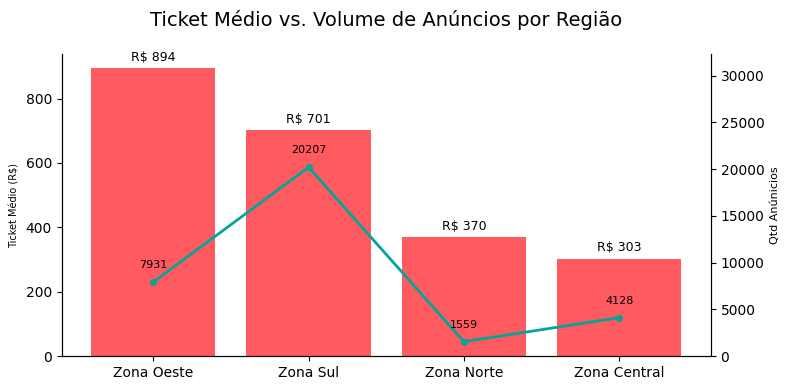

In [0]:
df_q1 = spark.sql("""
    SELECT 
        l.neighbourhood_group AS Regiao,
        ROUND(AVG(f.price), 2) AS Preco_Medio,
        count(f.ad_id) as Qtd_Anuncios
    FROM fact_listings f
    JOIN dim_location l ON f.id_location = l.id_location
    GROUP BY l.neighbourhood_group
    ORDER BY Preco_Medio DESC
""")

display(df_q1)

# Visualização Gráfica
import matplotlib.pyplot as plt
import seaborn as sns

# Converte Spark DF para Pandas para plotar
pdf_q1 = df_q1.toPandas()

fig, ax1 = plt.subplots(figsize=(8, 4))

cor_barra = '#FF5A5F' # Cinza para o volume (fundo/base)
cor_linha = '#00a699' # Vermelho Airbnb para o Preço (Destaque)

bars = ax1.bar(pdf_q1['Regiao'],pdf_q1['Preco_Medio'], color=cor_barra, label='Preço Médio')
ax1.set_ylabel('Ticket Médio (R$)', fontsize=7, color='black')
ax1.tick_params(axis='y', labelcolor='black')
ax1.grid(False) # Remove grid do fundo para não poluir

# Rótulos nas barras (Volume)
ax1.bar_label(bars, labels=[f"R$ {v:,.0f}" for v in pdf_q1['Preco_Medio']], padding=3, fontsize=9, color='black')

ax2 = ax1.twinx()
line = ax2.plot(pdf_q1['Regiao'],  pdf_q1['Qtd_Anuncios'], color=cor_linha, marker='o', linewidth=2, markersize=4, label='Qtd Anúncios')
ax2.set_ylabel('Qtd Anúnicios', fontsize=8)
ax2.tick_params(axis='y', labelcolor='black')
# Define um limite um pouco maior para a linha não colar no teto do gráfico
ax2.set_ylim(0, pdf_q1['Qtd_Anuncios'].max() * 1.6)

# Rótulos na linha (anuncios)
for i, txt in enumerate(pdf_q1['Qtd_Anuncios']):
    ax2.annotate(f"{txt:.0f}", (i, pdf_q1['Qtd_Anuncios'].iloc[i]), 
                 xytext=(0, 10), textcoords='offset points', 
                 ha='center', fontsize=8, color='black')

plt.title('Ticket Médio vs. Volume de Anúncios por Região', fontsize=14, pad=20)

ax1.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)

plt.tight_layout()
plt.show()

**Insight interessante:** Embora a Zona Sul seja o cartão-postal do Rio e concentre o maior volume de turistas, a Zona Oeste apresenta, surpreendentemente, um ticket médio 27% superior à tradicional Zona Sul.

Tal fato é explicado ao observarmos a densidade de anúncios. A Zona Oeste disponibiliza 7.933 anúncios, enquanto a Zona Sul oferta cerca de 2,5 vezes esse volume (ou 155% a mais). Essa disparidade evidencia que a Zona Sul sofre uma "diluição" do seu ticket médio, dada a gigantesca quantidade de imóveis compactos e antigos na plataforma.

Portanto, a Zona Sul mantém sua hegemonia em volume e liquidez ao abraçar o turismo de massa. Em contrapartida, a Zona Oeste se consolida como o destino de maior rentabilidade por diária, impulsionada pela oferta de imóveis mais novos e de maior metragem.

Já a Zona Norte, com um ticket médio 58% menor que a Zona Oeste e 48% menor que a Zona Sul, mostra-se um mercado maduro e estável, sustentado pela cultura boêmia tradicional e pelo fluxo de visitantes atraídos pelo emblemático Estádio do Maracanã.

Por fim, destaca-se o posicionamento estratégico da Zona Central. Mesmo apresentando um ticket médio 18% inferior ao da Zona Norte, o Centro sinaliza ser uma região subvalorizado, visto que disponibiliza mais que o dobro de imóveis (+165%) que a zona vizinha. Somado aos incentivos públicos de revitalização, como o Reviver Centro e Porto Maravilha, a região conta com uma logística privilegiada de fácil acesso ao Aeroporto Santos Dumont, VLT e Metrô, o que a torna uma aposta inteligente tanto para pequenos investidores quanto para empresas especializadas atentos na retomada do turismo cultural e corporativo.


###**2. Quais são os 10 bairros com a maior disponibilidade de anúncios?**

Bairro,Regiao,Total_Anuncios
Copacabana,Zona Sul,10500
Ipanema,Zona Sul,2802
Barra da Tijuca,Zona Oeste,2737
Centro,Zona Central,1974
Recreio dos Bandeirantes,Zona Oeste,1719
Botafogo,Zona Sul,1464
Leblon,Zona Sul,1427
Jacarepaguá,Zona Oeste,1290
Santa Teresa,Zona Central,1203
Flamengo,Zona Sul,748


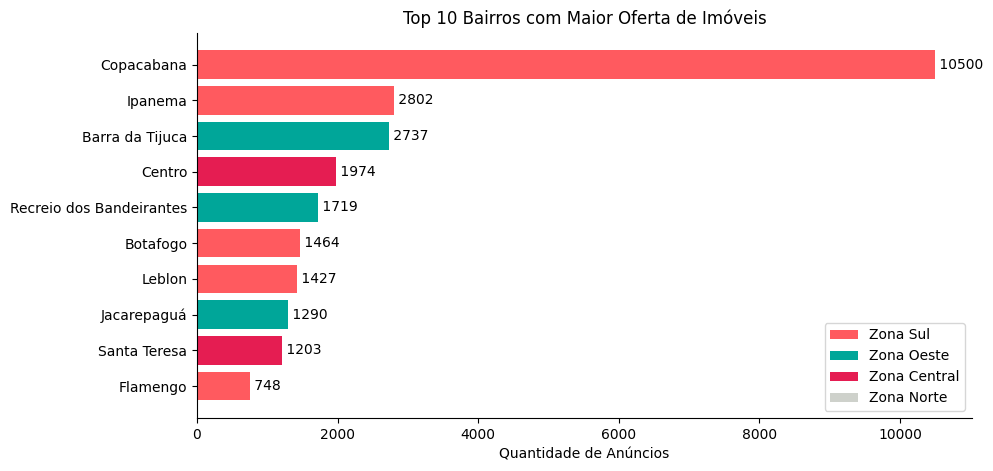

In [0]:
df_q2 = spark.sql("""
SELECT 
    l.neighbourhood AS Bairro,
    l.neighbourhood_group AS Regiao,
    COUNT(f.ad_id) AS Total_Anuncios
FROM fact_listings f
LEFT JOIN dim_location l ON f.id_location = l.id_location
WHERE l.neighbourhood_group IS NOT NULL
GROUP BY l.neighbourhood, l.neighbourhood_group
ORDER BY COUNT(f.ad_id) DESC
LIMIT 10;
""")

display(df_q2)

# VISUALIZACAO GRAFICA
pdf_q2 = df_q2.toPandas().sort_values('Total_Anuncios', ascending=True) # Ordena para o gráfico ficar crescente visualmente

plt.figure(figsize=(10, 5))

zone_colors_map = {
    'Zona Sul': '#FF5A5F',
    'Zona Oeste': '#00A699',
    'Zona Central': '#e51d52',
    'Zona Norte': '#ced1cb'
}
colors = [zone_colors_map.get(regiao, '#bdc3c7') for regiao in pdf_q2['Regiao']]

plt.barh(pdf_q2['Bairro'], pdf_q2['Total_Anuncios'], color=colors)


plt.title('Top 10 Bairros com Maior Oferta de Imóveis', fontsize=12)
plt.xlabel('Quantidade de Anúncios')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=zone_colors_map[z], label=z) for z in zone_colors_map]
plt.legend(handles=legend_elements, loc='lower right')

# Remove as linhas da borda superior e direita
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Rotulos nas barras
for index, value in enumerate(pdf_q2['Total_Anuncios']):
    plt.text(value, index, f' {value}', va='center')

plt.show()

**_Insight interessante:_** Evidenciando a análise anterior, nota-se a liderança da Zona Sul na preferência do mercado, ocupando 5 das 10 primeiras posições no ranking de oferta. Copacabana consolida-se como o líder absoluto em número de anúncios, detendo uma parcela de 40% da oferta entre os bairros listados, o que ratifica a fama turística da região.

A Barra da Tijuca não apenas lidera a oferta na Zona Oeste, concentrando 11% dos anúncios, como também atinge um patamar de volume tecnicamente empatado com Ipanema (apenas 63 anúncios de diferença). Esse dado confirma que o bairro se tornou uma alternativa consolidada à tradição da Zona Sul, embora o volume de ambos seja pequeno se comparado à escala massiva de Copacabana.

É importante destacar também a força do Centro. A região já supera em 15% a oferta de anúncios do Recreio dos Bandeirantes e está apenas 28% abaixo da disponibilidade da Barra da Tijuca. O grande trunfo é que, mesmo cobrando um ticket (preço) médio 66% menor que a Zona Oeste, o Centro se revela um investimento inteligente já que o valor mais acessível atrai mais hóspedes, compensando o preço menor com uma alta frequência de aluguéis (alto potencial de giro).

###**3. Quais regiões da cidade tem mais disponibilidade de apto inteiro, de apenas quarto inteiro e quarto compartilhado?**

Bairro,Tipo_Acomodacao,Qtd_Anuncios
Barra da Tijuca,Entire home/apt,2373
Barra da Tijuca,Private room,360
Barra da Tijuca,Shared room,4
Botafogo,Entire home/apt,1088
Botafogo,Private room,363
Botafogo,Shared room,10
Botafogo,Hotel room,3
Centro,Entire home/apt,1779
Centro,Private room,180
Centro,Shared room,15


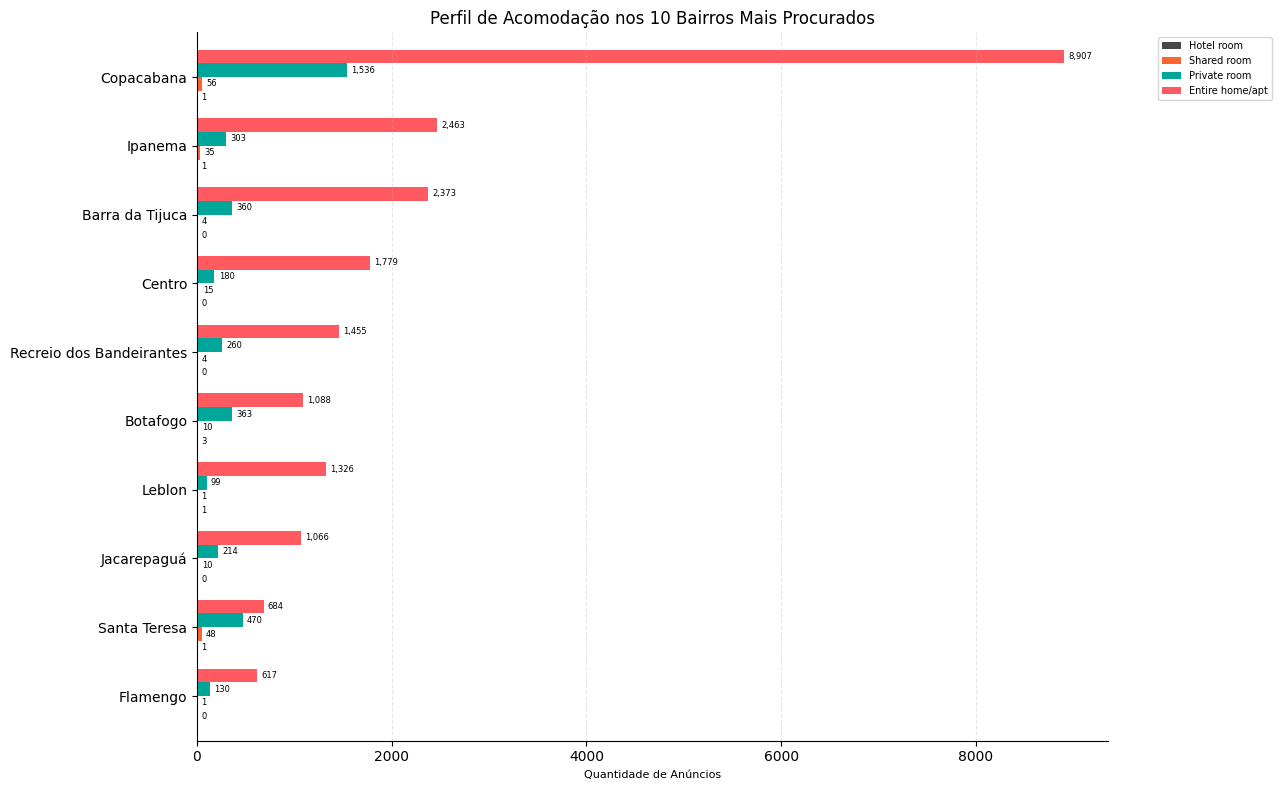

In [0]:
df_q3 = spark.sql("""
    WITH Top10_Bairros AS (
        SELECT l.neighbourhood
        FROM fact_listings f
        JOIN dim_location l ON f.id_location = l.id_location
        GROUP BY l.neighbourhood
        ORDER BY COUNT(f.ad_id) DESC
        LIMIT 10
    )
    SELECT 
        l.neighbourhood AS Bairro,
        a.room_type AS Tipo_Acomodacao,
        COUNT(f.ad_id) AS Qtd_Anuncios
    FROM fact_listings f
    JOIN dim_location l ON f.id_location = l.id_location
    JOIN dim_ad a ON f.ad_id = a.ad_id
    JOIN Top10_Bairros t ON l.neighbourhood = t.neighbourhood
    GROUP BY l.neighbourhood, a.room_type
    ORDER BY l.neighbourhood, Qtd_Anuncios DESC
""")

display(df_q3)

# Visualização Gráfica
pdf_q3 = df_q3.toPandas()

# pivotar dados
pivot_df = pdf_q3.pivot(index='Bairro', columns='Tipo_Acomodacao', values='Qtd_Anuncios').fillna(0)

# Ordena as colunas pelo valor total (soma) de cada tipo de acomodação, do maior para o menor
col_order = pivot_df.sum().sort_values(ascending=True).index
pivot_df = pivot_df[col_order]

# Reordenar os bairros: pro o maior ficar no topo visual do gráfico
pivot_df['Total_Row'] = pivot_df.sum(axis=1)
pivot_df = pivot_df.sort_values('Total_Row', ascending=True).drop(columns='Total_Row')

custom_colors_map = {
    'Entire home/apt': '#FF5A5F',
    'Private room': '#00A699',
    'Shared room': '#FC642D',
    'Hotel room': '#484848'
}
colors = [custom_colors_map.get(col, '#bdc3c7') for col in pivot_df.columns]

ax = pivot_df.plot(kind='barh', stacked=False, figsize=(13, 8), color=colors, width=0.8)

for container in ax.containers:
    ax.bar_label(container, fmt='{:,.0f}', padding=3, fontsize=6)

plt.title('Perfil de Acomodação nos 10 Bairros Mais Procurados', fontsize=12)
plt.xlabel('Quantidade de Anúncios', fontsize=8)
plt.ylabel('')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=7)

plt.gca().xaxis.grid(True, linestyle='--', alpha=0.3)

# Remove bordas
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Aumenta a margem direita para os rótulos não serem cortados
plt.subplots_adjust(right=0.95)

plt.tight_layout()
plt.show()

**_Insight interessante:_** A análise dos dados revela uma preferência incontestável por "Imóveis Inteiros" (Entire home/apt), que totalizam 21.812 anúncios. Isso indica que 84% da oferta nos bairros mais procurados é voltada para o aluguel de temporada com foco em privacidade total.

Entretanto, Santa Teresa figura como uma exceção a essa regra. No bairro, a predominância de imóveis inteiros cai para 57%, dividindo o mercado com os Quartos Privados, que representam expressivos 39% da oferta local. Esse dado valida quantitativamente o perfil turístico da região: um público mais jovem e mochileiros estrangeiros, dispostos a compartilhar espaços em troca da vivência boêmia e cultural característica do centro.

No extremo oposto, o Leblon é o bairro com a menor penetração de Quartos Privados, representando apenas 7% dos seus anúncios. A maioria dos demais bairros segue essa tendência de exclusividade, mantendo a oferta de quartos privados próxima ao patamar de 10%.


###**4. A plataforma está dominada por empresas especializadas ou por hosts que visam apenas em ter um renda extra?**

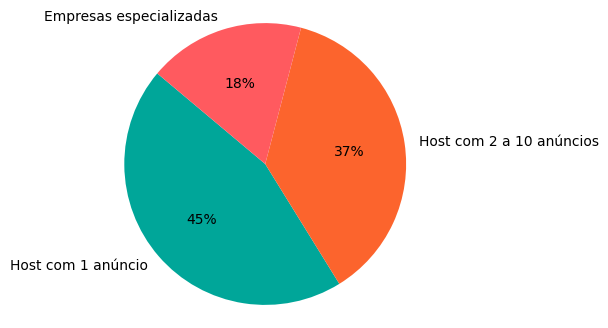

In [0]:
df_q5 = spark.sql("""
WITH Classificacao_Hosts AS (
    SELECT 
        host_id,
        CASE 
            WHEN host_total_listings_count = 1 THEN 'Host com 1 anúncio'
            WHEN host_total_listings_count BETWEEN 2 AND 10 THEN 'Host com 2 a 10 anúncios'
            ELSE 'Empresas especializadas'
        END AS Categoria_Host
    FROM dim_host
)

SELECT 
    c.Categoria_Host,
    COUNT(DISTINCT f.host_id) AS Qtd_Hosts,
    COUNT(f.ad_id) AS Qtd_Anuncios_Controlados,
    ROUND(AVG(f.price), 2) AS Preco_Medio_Cobrado
FROM fact_listings f
JOIN Classificacao_Hosts c ON f.host_id = c.host_id
GROUP BY 1
ORDER BY Qtd_Anuncios_Controlados DESC;
""")

#display(df_q5)

# Visualização Gráfica
pdf_q5 = df_q5.toPandas()

plt.figure(figsize=(4, 4))

plt.pie(pdf_q5['Qtd_Anuncios_Controlados'], 
        labels=pdf_q5['Categoria_Host'], 
        autopct='%1.0f%%', 
        startangle=140, 
        colors=['#00A699', '#FC642D', '#FF5A5F'])

plt.axis('equal') 
plt.show()

**_Insight interessante:_** O perfil dos hosts com apenas 1 anúncio são a maioria do mercado englobando 45% dos anúncios da cidade na plataforma. Isso corrobora a premissa original do Airbnb como uma ferramenta de economia compartilhada e geração de renda extra para moradores locais.

No entanto, vemos uma tendência clara de profissionalização. Se somarmos os hosts que administram 2 a 10 imóveis, com as "Empresas Especializadas", que administram mais de 10 imóveis, esse grupo detém 55% do marketshare, formando a maioria dos hosts.

Isso indica que o mercado carioca atingiu um nível de maturidade onde o aluguel por temporada de múltiplos imóveis se tornou um modelo de negócio predominante, superando a premissa de renda extra inicial. As grandes empresas de gestão detem uma parcela relevante de 18% do marketshare, e mesmo não monopolizando o setor, sugere uma tendência de expansão.

###**5. Quais bairros garantem maior taxa de ocupação?**

Regiao,Bairro,Dias_Livres_Ano,Dias_Ocupados_Ano,Tx_Ocupacao,Qtd_Anuncios
Zona Oeste,Guaratiba,99.0,266.0,73.0,152
Zona Oeste,Vargem Pequena,113.0,252.0,69.0,163
Zona Oeste,Itanhangá,119.0,246.0,67.0,160
Zona Oeste,Recreio dos Bandeirantes,128.0,237.0,65.0,1719
Zona Oeste,Jacarepaguá,131.0,234.0,64.0,1290
Zona Sul,Gávea,144.0,221.0,61.0,186
Zona Norte,Tijuca,147.0,218.0,60.0,350
Zona Central,Santa Teresa,153.0,212.0,58.0,1203
Zona Sul,Vidigal,159.0,206.0,56.0,334
Zona Oeste,Barra da Tijuca,159.0,206.0,56.0,2737


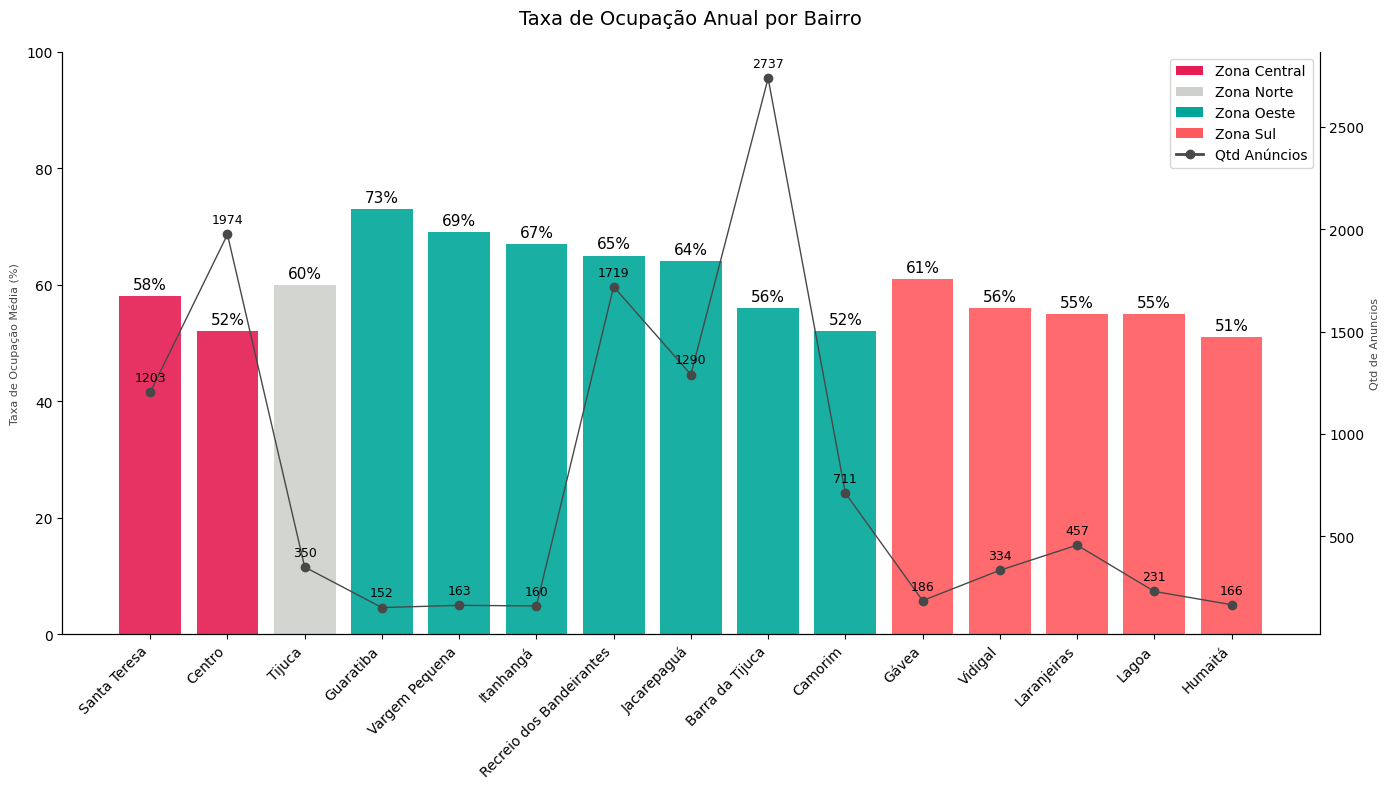

In [0]:
df_q6 = spark.sql("""
WITH Ocupacao_Anual AS(
    SELECT
       ROUND(AVG(f.availability_365), 0) AS dias_ocupados_ano,
       (365 - ROUND(AVG(f.availability_365), 0)) AS dias_livres_ano,
       l.neighbourhood AS Bairro,
       l.neighbourhood_group as Regiao,
       count(f.ad_id) as qtd_anuncios
    FROM fact_listings f
    JOIN dim_location l ON f.id_location = l.id_location
    GROUP BY l.neighbourhood, l.neighbourhood_group
    HAVING COUNT(f.ad_id) >= 150
)

SELECT 
    l.neighbourhood_group AS Regiao,
    l.neighbourhood AS Bairro,
    o.dias_livres_ano AS Dias_Livres_Ano,
    o.dias_ocupados_ano AS Dias_Ocupados_Ano,
    ROUND((o.dias_ocupados_ano/365)*100,0) AS Tx_Ocupacao,
    o.qtd_anuncios AS Qtd_Anuncios
FROM fact_listings f
JOIN dim_location l ON f.id_location = l.id_location
JOIN Ocupacao_Anual o ON l.neighbourhood = o.bairro
GROUP BY l.neighbourhood, o.dias_livres_ano, o.dias_ocupados_ano, l.neighbourhood_group, o.qtd_anuncios
ORDER BY Tx_Ocupacao DESC
LIMIT 15;
""")

display(df_q6)

# Visualização Gráfica

# ascending=[True, False] significa: Região A-Z, Ocupação Maior->Menor
pdf_q6 = df_q6.toPandas().sort_values(['Regiao', 'Tx_Ocupacao'], ascending=[True, False])

fig, ax1 = plt.subplots(figsize=(14, 8))

zone_colors_map = {
    'Zona Sul': '#FF5A5F',      # vermelho
    'Zona Oeste': '#00A699',    # verde
    'Zona Central': '#e51d52',  # rosa escuro
    'Zona Norte': '#ced1cb'     # cinza claro
}
colors = [zone_colors_map.get(zona, '#bdc3c7') for zona in pdf_q6['Regiao']]

from matplotlib.patches import Patch
from matplotlib.lines import Line2D
sorted_zones = sorted([z for z in pdf_q6['Regiao'].unique() if z in zone_colors_map])

legend_elements = [Patch(facecolor=zone_colors_map[z], label=z) for z in sorted_zones]
legend_elements.append(Line2D([0], [0], color='#484848', lw=2, marker='o', label='Qtd Anúncios'))
ax1.legend(handles=legend_elements, loc='upper right')

# eixo X = bairro, eixo Y = taxa
bars = ax1.bar(pdf_q6['Bairro'], pdf_q6['Tx_Ocupacao'], color=colors, alpha=0.9, label='Taxa de Ocupação')
ax1.set_ylabel('Taxa de Ocupação Média (%)', fontsize=8, color='#484848')
ax1.set_ylim(0, 100) # 0 a 100%

# rotulo no eixo X
ax1.set_xticklabels(pdf_q6['Bairro'], rotation=45, ha='right')

# rotulo nas barras
ax1.bar_label(bars, fmt='%.0f%%', padding=3, fontsize=11)

# linha: qtd de anúncios
ax2 = ax1.twinx() # Cria o eixo secundário Y
ax2.plot(pdf_q6['Bairro'], pdf_q6['Qtd_Anuncios'], color='#484848', marker='o', linewidth=1, linestyle='-')
ax2.set_ylabel('Qtd de Anuncios', fontsize=8, color='#484848')

# rotulo na linha
for i, txt in enumerate(pdf_q6['Qtd_Anuncios']):
    ax2.annotate(txt, (i, pdf_q6['Qtd_Anuncios'].iloc[i]), 
                 xytext=(0, 8), textcoords='offset points', 
                 ha='center', fontsize=9, color='#000000')

plt.title('Taxa de Ocupação Anual por Bairro', fontsize=14, pad=20)


#legenda regioes
ax1.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)

plt.tight_layout()
plt.show()


**_Insight interessante:_**  A região central valida a aposta na revitalização (Reviver Centro) e turismo cultural. Santa Teresa (58%) e Centro (52%) mantêm ocupação competitiva, sendo que o Centro sustenta essa taxa mesmo com alta oferta (1.974 anúncios).

Na Zona Oeste, a busca por natureza e exclusividade garante as maiores taxas da cidade. A escassez de oferta em Guaratiba (73%) e Vargem Pequena (69%) gera demanda represada, enquanto o Recreio (65%) consolida-se como a alternativa robusta à Zona Sul.

A Barra da Tijuca tem o maior portfólio dentre os bairros listados somando 2.739 anúncios com taxa de 56% que não indica baixa procura, mas sim alta liquidez diluída. O volume massivo confirma o bairro como um mercado seguro e de giro constante.

Na Zona Sul, a demanda transborda para bairros "satélites". A Gávea (61%) supera a média da região ao oferecer proximidade estratégica com melhor custo-benefício. Já o Vidigal (56%) destaca-se pela busca por experiência autêntica e vista panorâmica.